# Project Milestone Two | <font color = 'salmon'>Team: Kiran Prakash, Brad Ballinger, Arun Ram</font>
## <font color = 'green'>HUFFINGTON POST DATASET

**Data Preparation and Model Exploration**
**Due:** <font color = 'red'>*Midnight on November 16th* </font>with usual 2-hour grace period — **worth 100 points**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans:
1. prepare the data
2. train three models of increasing sophistication, and
3. Evaluate their results using Keras and TensorFlow.


You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


# Imports

In [1]:
# ============================================
# Useful Imports
# ============================================
%pip -q install -U keras keras-hub tensorflow tensorflow-text datasets evaluate
# --- Standard Libraries
import os
import time
import datetime
import math
import random
import re
import nltk
# import Evaluate
from nltk.corpus import stopwords
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import                                      matplotlib.pyplot as plt
import                                      seaborn as sns              # optional
import                                      matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import                                      spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import                            tqdm                # optional (nice for loops)
from IPython.display import                 display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf

from tensorflow.keras import                layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import      Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import     Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization, TextVectorization
)
!pip install -q --upgrade keras keras-nlp

import                                      keras
import                                      keras_nlp
from keras.callbacks import                 ModelCheckpoint

from keras.losses import                    SparseCategoricalCrossentropy


# --- (Optional) Classical ML Baseline Tools
from sklearn.pipeline import                Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import            LogisticRegression
from sklearn.metrics import                 accuracy_score
from sklearn.model_selection import         train_test_split
from sklearn.utils.class_weight import      compute_class_weight
from sklearn.preprocessing import           LabelEncoder

# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS





[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:

sns.set_theme(font_scale=0.9)
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 4
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

In [ ]:
# If needed (in a new env):
# %pip install -U datasets pillow

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict, load_from_disk
from datasets.features import ClassLabel

In [16]:
# from google.colab import drive

# # Mount Google Drive
# drive.mount('/content/drive')

# Functions

In [4]:
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

### plot_learning_curves

In [5]:
# --- Plotting Function ---
def plot_learning_curves(hist, title, verbose = True):
    """
    Plots the learning curves for loss and accuracy.
    Handles both standard 'accuracy' and 'sparse_categorical_accuracy' keys.
    """
    history_dict  = hist.history
    val_losses    = history_dict['val_loss']
    min_val_loss  = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)

    # --- Dynamically find accuracy keys ---
    if 'sparse_categorical_accuracy' in history_dict:
        acc_key     = 'sparse_categorical_accuracy'
        val_acc_key = 'val_sparse_categorical_accuracy'

    elif 'accuracy' in history_dict:
        acc_key     = 'accuracy'
        val_acc_key = 'val_accuracy'

    else:
        print("Error: Could not find 'accuracy' or 'sparse_categorical_accuracy' in history keys.")
        return

    # --- End of dynamic key finding ---


    # Use the correct key: 'val_sparse_categorical_accuracy' or 'val_accuracy'
    val_acc_at_min_loss = history_dict[val_acc_key][min_val_epoch]

    epochs    = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs  = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label = 'Train Loss')
    axs[0].plot(epochs, hist.history['val_loss'], label = 'Val Loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color = 'red', marker = 'x', s = 50, label = 'Min Val Loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    # Use the correct key: 'sparse_categorical_accuracy' or 'accuracy'
    axs[1].plot(epochs, history_dict[acc_key], label='Train Acc')
    # Use the correct key: 'val_sparse_categorical_accuracy' or 'val_accuracy'
    axs[1].plot(epochs, history_dict[val_acc_key], label = 'Val Acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color = 'red', marker = 'x', s = 50, label = 'Acc @ Min Val Loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Min. Validation Loss: {min_val_loss:.4f} at epoch {min_val_epoch + 1}")
        print(f"Validation Accuracy @ Min. Loss: {val_acc_at_min_loss:.4f}")

### train_and_test

In [6]:
def train_and_test(model,
                   title            = "Learning Curves",
                   epochs           = 300,                   # Just needs to be bigger than early stopping point
                   optimizer        = "Adam",
                   lr_schedule      = 1e-3,                  # Adam defaults
                   clipnorm         = None,
                   batch_size       = 128,
                   loss             = "sparse_categorical_crossentropy",
                   metrics          = ["accuracy"],
                   use_early_stopping = True,
                   patience         = 5,
                   min_delta        = 0.0001,
                   callbacks        = [],                     # for extra callbacks other than early stopping
                   use_reduce_on_plateau = False,           # NEW FLAG
                   rlrop_patience  = 5,                      # NEW PARAMETER
                   rlrop_factor    = 0.5,                    # NEW PARAMETER
                   verbose         = 0,
                   return_history  = False
                  ):


    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate = lr_schedule, clipnorm = clipnorm)
    else:
        opt = optimizer

    #Compiling the model
    model.compile(optimizer = opt,
                  loss      = loss,
                  metrics   = metrics
                 )

# --- CALLBACK ASSEMBLY ---
    cbs = []

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        )
        cbs.append(early_stop)

    if use_reduce_on_plateau:
        reduce_lr = ReduceLROnPlateau(
            monitor   = 'val_loss',    # Metric to monitor
            factor    = rlrop_factor,  # Factor by which LR will be reduced (e.g., 0.5)
            patience  = rlrop_patience, # Number of epochs with no improvement
            min_delta = min_delta,     # Only reduce for significant stagnation
            cooldown  = 0,
            min_lr    = 1e-8,
            verbose   = 1,
        )
        cbs.append(reduce_lr)

    cbs.extend(callbacks)

    # start timer
    start = time.time()

    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs          = epochs,
                            batch_size      = batch_size,
                            validation_data = (X_val, y_val),
                            callbacks       = cbs,
                            verbose         = verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs            = epochs,
                            batch_size        = batch_size,
                            validation_split  = 0.2,
                            callbacks         = cbs,
                            verbose           = verbose
                           )

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch       = np.argmin(history.history['val_loss'])

    # Retrieve the values at that epoch
    min_val_loss        = history.history['val_loss'][min_val_epoch]

    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    end             = time.time()
    execution_time  = format_hms(end - start)
    print(f"\nExecution Time: " + execution_time)

    # Print out results

    print(f"\nFinal Train Loss:       {history.history['loss'][-1]:.4f}")
    print(f"Final Train Acc:          {history.history['accuracy'][-1]:.4f}")
    print(f"Final Val Loss:           {history.history['val_loss'][-1]:.4f}")
    print(f"Final Val Acc:            {history.history['val_accuracy'][-1]:.4f}")
    print(f"Min Val Loss:             {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Val Acc @ Min Loss:       {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss:              {test_loss:.4f}")
    print(f"Test Acc:                 {test_accuracy:.4f}")

    print(f"\nVal-Test Acc Gap:       {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    results             = {}


    # Store accuracy in results
    results[title] = (val_acc_at_min_loss, min_val_epoch + 1)

    # Store all information about run in parameter_settings

    global parameter_settings
    entry = {
        "title":                title,
        "timestamp":            time.strftime('%Y-%m-%dT%H:%M:%S', time.localtime()),
        'execution_time':       execution_time,
        "epochs":               int(epochs),
        "optimizer":            optimizer,
        "lr_schedule":          lr_schedule,
        "clipnorm":             clipnorm,
        "loss":                 loss,
        "batch_size":           batch_size,
        "use_early_stopping":   use_early_stopping,
        "patience":             patience,
        "min_delta":            min_delta,

        "use_reduce_on_plateau":use_reduce_on_plateau, # Add RLR-specific parameters to the log for easy comparison
        "rlrop_patience":       rlrop_patience if use_reduce_on_plateau else None,
        "rlrop_factor":         rlrop_factor if use_reduce_on_plateau else None,
        "callbacks":            _summarize_callbacks(callbacks),
        "Final Train Loss" :    history.history['loss'][-1],
        "Final Train Acc" :     history.history['accuracy'][-1],
        "Final Val Loss" :      history.history['val_loss'][-1],
        "Final Val Acc" :       history.history['val_accuracy'][-1],
        "Min Val Loss" :        min_val_loss,
        "Min Val Loss Epoch" :  min_val_epoch,
        "Val Acc @ Min Loss" :  val_acc_at_min_loss,
        "Test Loss" :           test_loss,
        "Test Acc" :            test_accuracy,
        "Val-Test Acc Gap:" :   abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)

    if return_history:
        return history
    # Only return the dictionary if return_history is False AND the user
    # explicitly assigns the result to a variable. Otherwise, return None
    # to avoid implicit printing in Colab.
    # Return parameter_settings if return_history is True to
    # keep the historical behavior for the rest of the file.
    return parameter_settings if return_history else None


def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

parameter_settings  = {}
def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key      = lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse  = True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

### create_bi_gru_flexible

In [7]:
def create_bi_gru_flexible_model(
    vocab_size,
    embedding_dim,
    num_classes,
    recurr_dim      = 128,
    rnn_type        = "GRU",          # Options: "GRU" or "LSTM"
    pooling         = "max",          # Options: "max" or "avg"
    dropout_rates   = (0.3, 0.4), # Tuple for two dropout layers
    use_batchnorm   = True,
    l2_reg          = 1e-4
):
    """
    Creates a flexible Bi-directional Reucrring NN model with some flexible input options.

    Parameters:
        vocab_size (int):     Size of the vocabulary.
        embedding_dim (int):  Dimension of the embedding layer.
        num_classes (int):    Number of output classes.
        recurr_dim (int):     Units for GRU/LSTM (default 128).
        rnn_type (str):       "GRU" or "LSTM".
        pooling (str):        "max" for GlobalMaxPooling1D or "avg" for GlobalAveragePooling1D.
        dropout_rates (tuple): Dropout rates for two layers (default (0.3, 0.4)).
        use_batchnorm (bool): Whether to include BatchNormalization.
        l2_reg (float):       L2 regularization factor for Dense layer.

    Returns:
        tf.keras.Model: Configured Bi-directional RNN model.

    """

    model = tf.keras.Sequential()

    #  Embedding Layer
    model.add(layers.Embedding(
        input_dim   = vocab_size,
        output_dim  = embedding_dim,
        mask_zero   = True
    ))

    #  Choose RNN type
    if rnn_type.upper() == "LSTM":
        rnn_layer = layers.LSTM(units = recurr_dim, return_sequences = True)
    else:
        rnn_layer = layers.GRU(units = recurr_dim, return_sequences = True)

    #  Bi-directional wrapper
    model.add(layers.Bidirectional(rnn_layer))

    # Pooling Layer
    if pooling == "avg":
        model.add(layers.GlobalAveragePooling1D())
    else:
        model.add(layers.GlobalMaxPooling1D())

    #   BatchNormalization
    if use_batchnorm:
        model.add(layers.BatchNormalization())

    # Dropout + Dense + Dropout
    model.add(layers.Dropout(dropout_rates[0]))
    model.add(layers.Dense(
        units               = 128,
        activation          = "relu",
        kernel_regularizer  = regularizers.l2(l2_reg)
    ))
    model.add(layers.Dropout(dropout_rates[1]))

    # Output Layer
    model.add(layers.Dense(num_classes, activation = "softmax"))

    return model


### plot_history

In [8]:
def plot_history(history, model_name, time_taken):
    """Plots the training and validation loss and accuracy."""
    try:
        history_dict  = history.history
        acc           = history_dict['sparse_categorical_accuracy']
        val_acc       = history_dict['val_sparse_categorical_accuracy']
        loss          = history_dict['loss']
        val_loss      = history_dict['val_loss']
    except KeyError:
        print(f"Warning: Could not find 'sparse_categorical_accuracy' in history. Using 'accuracy'.")
        acc           = history_dict['accuracy']
        val_acc       = history_dict['val_accuracy']
        loss          = history_dict['loss']
        val_loss      = history_dict['val_loss']


    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.suptitle(f"{model_name} (Train time: {time_taken:.2f}s)", fontsize=16)

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'bo-', label='Training acc')
    plt.plot(epochs_range, val_acc, 'ro-', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'bo-', label='Training loss')
    plt.plot(epochs_range, val_loss, 'ro-', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### run_experiment

In [9]:
def run_experiment_p3(model_name, preproc_cls, model_cls, preset, max_len, lr, batch_size):
    print(f"\n--- Running Model: {model_name} ---")

    start = time.time()

    # 1. Model Setup (Preproc and Classifier based on parameters)
    preproc = preproc_cls.from_preset(preset, sequence_length = max_len)
    model   = model_cls.from_preset(preset, num_classes=2, preprocessor=preproc)

    # 2. Compile (Fixed LR)
    model.compile(
        optimizer = keras.optimizers.Adam(lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics   = [keras.metrics.SparseCategoricalAccuracy(name="acc")],
    )

    # 3. Train
    cb = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size = batch_size,
        callbacks=cb,
        verbose=1,
    )

    # 4. Evaluation
    min_val_loss_idx  = np.argmin(history.history['val_loss'])
    best_val_acc      = history.history['val_acc'][min_val_loss_idx]

    logits            = model.predict(X_te, batch_size = EVAL_BATCH, verbose=0)
    y_pred            = logits.argmax(axis=-1)

    acc_metric        = evaluate.load("accuracy")
    f1_metric         = evaluate.load("f1")
    test_acc          = acc_metric.compute(predictions=y_pred, references=y_te)["accuracy"]
    test_f1           = f1_metric.compute(predictions=y_pred, references=y_te)["f1"]

    end               = time.time() - start
    elapsed_time      = time.strftime("%H:%M:%S", time.gmtime(end))
    time_stamp        = time.strftime("%Y-%m-%d_%H-%M-%S")

    print(f"-> Best Validation Acc: {best_val_acc:.4f}")
    print(f"-> Test Acc: {test_acc:.4f}, Test F1: {test_f1:.4f}")
    print(f"-> Elapsed Time: {elapsed_time}")

    return {
        "Model":        model_name,
        "Best_Val_Acc": best_val_acc,
        "Test_Acc":     test_acc,
        "Test_F1":      test_f1,
        "elapsed_time":         elapsed_time,
        'time_stamp':   time_stamp,
    }

### run_kerasNLP_experiment

In [10]:
def run_kerasNLP_experiment(model_name, preproc_cls, model_cls, preset,
                            x_train, y_train, x_val, y_val, x_test, y_test,
                            num_classes, max_len, epochs, batch_size, learning_rate):
    """
    Runs a single training and evaluation experiment for a given KerasNLP model.
    Uses:
      - Built-in preprocessing (no manual tokenization)
      - Checkpoint callback for best weights
    Returns:
      history, test_loss, test_acc, training_time, best_val_loss, best_val_acc
    """
    print(f"[{model_name}] Initializing model and preprocessor...")
    print(f"Preset: {preset}, Max Length: {max_len}")
    start = time.time()

    # Initialize preprocessor and classifier
    preprocessor  = preproc_cls.from_preset(preset, sequence_length=max_len)
    classifier    = model_cls.from_preset(
        preset,
        num_classes   = num_classes,
        preprocessor  = preprocessor
    )

    # Compile model
    classifier.compile(
        optimizer = keras.optimizers.Adam(learning_rate = learning_rate),
        loss      = keras.losses.SparseCategoricalCrossentropy(from_logits = True),
        metrics   = [keras.metrics.SparseCategoricalAccuracy()]
    )

    # Checkpoint callback
    best_model_filepath = f"{model_name}_best_weights.weights.h5"
    checkpoint          = keras.callbacks.ModelCheckpoint(
        filepath          = best_model_filepath,
        monitor           = 'val_loss',
        mode              = 'min',
        save_best_only    = True,
        save_weights_only = True,
        verbose           = 1
    )

    # Train model
    print(f"[{model_name}] Starting training...")
    start_time  = time.time()
    history     = classifier.fit(
        x_train.tolist(),
        y_train,
        validation_data = (x_val.tolist(), y_val),
        epochs          = epochs,
        batch_size      = batch_size,
        callbacks       = [checkpoint]
    )
    end             = time.time()
    training_time   = format_hms(end - start)
    print(f"[{model_name}] Training finished in {training_time}.")

    # Load best weights
    print(f"[{model_name}] Loading best weights...")
    classifier.load_weights(best_model_filepath)

    # Evaluate on validation set
    val_score     = classifier.evaluate(x_val.tolist(),
                                        y_val,
                                        batch_size = batch_size,
                                        verbose    = 0
                                        )
    best_val_loss = val_score[0]
    best_val_acc  = val_score[1]
    print(f"[{model_name}] Best Val Loss: {best_val_loss:.4f}, Best Val Acc: {best_val_acc:.4f}")

    # Evaluate on test set
    test_loss, test_acc = classifier.evaluate(x_test.tolist(),
                                              y_test,
                                              batch_size = batch_size
                                              )
    print(f"[{model_name}] Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

    # Clean up weights file
    try:
        os.remove(best_model_filepath)
    except OSError as e:
        print(f"Error removing temporary weights file: {e}")

    return history, test_loss, test_acc, training_time, best_val_loss, best_val_acc

### load_json_for_transfer_model

In [11]:
def load_json_for_transfer_model(filepath):
    """
    Loads and preprocesses the Huffington Post JSONL file.
    This function is based on the logic from Milestone_02_Arun_v1.
    """
    print(f"Loading data from {filepath}...")

    start = time.time()
    df = pd.read_json(filepath, lines=True)


    # Combine headline and short_description (as done in Milestone_02)
    # Fill potential NaN values with empty strings before combining
    df['text'] = df['headline'].fillna('') + ' ' + df['short_description'].fillna('')

    # Keep only necessary columns, DROP any rows w/ missing data
    df = df[['text', 'category']]
    df = df.dropna()

    #  number of unique classes
    num_classes = df['category'].nunique()
    print(f"Found {num_classes} unique categories.")

    # Create integer labels for categories
    df['category_code'] = df['category'].astype('category').cat.codes

    # Create MAPPING for later reference
    category_map = dict(enumerate(df['category'].astype('category').cat.categories))

    # SPLIT into training and test sets (80% train, 20% test)
    train_df, test_df = train_test_split(
        df,
        test_size     = 0.2,
        random_state  = 42,
        stratify      = df['category_code']
    )

    # 2. Split the training set again into train and validation (90% train, 10% val from the original 80%)
    train_df, val_df = train_test_split(
        train_df,
        test_size     = 0.1,
        random_state  = 42,
        stratify      = train_df['category_code']
    )

    # Extract data as pandas Series (Keras models can accept this directly)
    # We will pass the RAW TEXT (x_train) to the KerasNLP models,
    # which will handle their own tokenization.
    x_train = train_df['text']
    y_train = train_df['category_code']

    x_val = val_df['text']
    y_val = val_df['category_code']

    x_test = test_df['text']
    y_test = test_df['category_code']

    print(f"Training examples:   {len(x_train)}")
    print(f"Validation examples: {len(x_val)}")
    print(f"Test examples:       {len(x_test)}")

    end = time.time()
    execution_time = format_hms(end - start)
    print(f"Execution time: {execution_time}")

    return (x_train, y_train), (x_val, y_val), (x_test, y_test), num_classes, category_map

### load_preprocess

In [22]:

def load_preprocess(filepath, random_state = 42, sample_size = None):
    print(f"Loading data from {filepath}...")

    start = time.time()

    df          = pd.read_json(filepath, lines = True)
    df['text']  = df['headline'].fillna('') + ' ' + df['short_description'].fillna('')
    df          = df[['text', 'category']].dropna()

    if sample_size:
        df = df.sample(n = sample_size, random_state = random_state)

    df['category_code'] = df['category'].astype('category').cat.codes
    category_map        = dict(enumerate(df['category'].astype('category').cat.categories))
    num_classes         = df['category_code'].nunique()

    train_df, test_df = train_test_split(df, test_size = 0.2, stratify = df['category_code'], random_state = random_state)
    train_df, val_df  = train_test_split(train_df, test_size = 0.1, stratify = train_df['category_code'], random_state = random_state)

    end             = time.time()
    execution_time  = format_hms(end - start)
    # print(f"Execution time: {execution_time}")
    print(f'Loading complete in {execution_time} seconds.')

    return train_df, val_df, test_df, num_classes, category_map


## tokenize and build dataset

In [13]:

def tokenize_dataset(texts, preprocessor):
    """
      Pre-tokenizes using KerasNLP
    """
    return preprocessor.tokenizer(texts)

# ---  Create tf.data.Dataset ---
def make_tf_dataset(x, y, batch_size = 16, shuffle = True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(x))

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Problem 1 – Data Preparation and Splits (20 pts)

## Goals
Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

## Steps to Follow


1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.

In [14]:
# Your code here; add as many cells as you need but make it clear what the structure is.


### 1. Load & Summarize

In [23]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# huff_all = load_dataset("json", data_files = URL, split = "train")

# path = '/content/drive/My Drive/DX703/huffpost_data/'
# # huff_all.save_to_disk(path)        # save

# from datasets import load_from_disk
# huff_all = load_from_disk(URL)  # reload when needed


huff_all = pd.read_json(URL, lines=True)
# huff_all

In [25]:
huff_all

,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26
3,ENTERTAINMENT,Jim Carrey Blasts 'Castrato' Adam Schiff And D...,Ron Dicker,https://www.huffingtonpost.com/entry/jim-carre...,The actor gives Dems an ass-kicking for not fi...,2018-05-26
4,ENTERTAINMENT,Julianna Margulies Uses Donald Trump Poop Bags...,Ron Dicker,https://www.huffingtonpost.com/entry/julianna-...,"The ""Dietland"" actress said using the bags is ...",2018-05-26
...,...,...,...,...,...,...
200848,TECH,RIM CEO Thorsten Heins' 'Significant' Plans Fo...,"Reuters, Reuters",https://www.huffingtonpost.com/entry/rim-ceo-t...,Verizon Wireless and AT&T are already promotin...,2012-01-28
200849,SPORTS,Maria Sharapova Stunned By Victoria Azarenka I...,,https://www.huffingtonpost.com/entry/maria-sha...,"Afterward, Azarenka, more effusive with the pr...",2012-01-28
200850,SPORTS,"Giants Over Patriots, Jets Over Colts Among M...",,https://www.huffingtonpost.com/entry/super-bow...,"Leading up to Super Bowl XLVI, the most talked...",2012-01-28
200851,SPORTS,Aldon Smith Arrested: 49ers Linebacker Busted ...,,https://www.huffingtonpost.com/entry/aldon-smi...,CORRECTION: An earlier version of this story i...,2012-01-28


In [26]:

# print(huff_all)
# print("Columns:", huff_all.column_names)
# print(f"Total rows: {len(huff_all):,}")

In [27]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

Exception ignored in: <function tqdm.__del__ at 0x3172be7a0>
Traceback (most recent call last):
  File "/Users/arunram/Desktop/Data Science/BU_MSDS/Module 7/tf-metal-venv/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/arunram/Desktop/Data Science/BU_MSDS/Module 7/tf-metal-venv/lib/python3.10/site-packages/tqdm/notebook.py", line 273, in close
    if self.disable:
AttributeError: 'tqdm' object has no attribute 'disable'


KeyError: 0

In [ ]:
# Show k random lines: "headline [SEP] short_description"

k     = 5
seed  = 7
rng   = random.Random(seed)
idxs  = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

In [29]:
huff_df = huff_all
# huff_df = huff_all.to_pandas()
# path    = '/Users/arunram/Desktop/Data Science/BU_MSDS/Module 7/News_Category_Dataset_v2.json'
# huff_df = pd.read_json(huff_all, lines=True)
# huff_df.head()

In [30]:
huff_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   category           200853 non-null  object        
 1   headline           200853 non-null  object        
 2   authors            200853 non-null  object        
 3   link               200853 non-null  object        
 4   short_description  200853 non-null  object        
 5   date               200853 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 9.2+ MB


In [31]:
num_samples, num_features = huff_df.shape
print(f'Number of samples: {num_samples:,}\nNumber of features: {num_features}')

# Number distinct categories / classes
num_classes = huff_df['category'].nunique()
print(f"Number of distinct categories/classes: {num_classes}")

# Verify  number of classes
expected_classes = 41
if num_classes == expected_classes:
    print(f"The number of classes matches the expected {expected_classes}.")
else:
    print(f"Warning: The number of classes ({num_classes}) does not match the expected {expected_classes}.")

Number of samples: 200,853
Number of features: 6
Number of distinct categories/classes: 41
The number of classes matches the expected 41.


In [32]:
#  example records
print("\n--- Example Records (5 random samples) ---")
huff_df[['category','date', 'headline', 'short_description']].sample(5)


--- Example Records (5 random samples) ---


,category,date,headline,short_description
56274,CRIME,2016-06-12,Shooting Rampage Results In 'Mass Casualties' ...,"ORLANDO, Fla., June 12 (Reuters) - A gunman ki..."
9929,POLITICS,2017-12-09,"Donald Trump Lashes Out At CNN, ABC Over Repor...","The president criticized the ""fake news media""..."
163271,STYLE & BEAUTY,2013-03-07,Model Kate Moss Walks Louis Vuitton RTW Fall 2013,Golden girl model Kate Moss wowed in her usual...
190013,DIVORCE,2012-05-24,7 Ways Single Moms Cope With Loneliness,“Am I the only single mom feeling lonely out t...
13564,POLITICS,2017-10-22,Sen. Sherrod Brown: Steve Bannon 'Is A White S...,"Echoing comments by Rep. Frederica Wilson, he ..."


In [33]:
# MISSING VALUES
print("\n--- Missing Data ---")
missing_values = huff_df.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")
print("Missing data found.") if missing_values.sum() > 0 else print("No missing data found.")



--- Missing Data ---
Missing values per column:
category             0
headline             0
authors              0
link                 0
short_description    0
date                 0
dtype: int64

No missing data found.


In [34]:

# DUPLICATES
print("\n--- Duplicate Entries ---")
duplicates        = huff_df.duplicated(subset=['headline', 'short_description'])
# duplicates        = huff_df.duplicated()

duplicates_count  = duplicates.sum()
print(f"Number of duplicate rows (based on text content): {duplicates_count}\n")
print("Duplicates found.") if duplicates_count > 0 else print("No duplicate entries found.")

# show duplicate entries
if duplicates_count > 0:
    print("Duplicate entries:")
    display(huff_df[duplicates])


--- Duplicate Entries ---
Number of duplicate rows (based on text content): 488

Duplicates found.
Duplicate entries:


,category,headline,authors,link,short_description,date
9490,PARENTS,The Funniest Tweets From Parents This Week,Hollis Miller,https://www.huffingtonpost.com/entry/funniest-...,"Kids may say the darndest things, but parents ...",2017-12-15
10335,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Matthew Jacobs,https://www.huffingtonpost.com/entry/octavia-s...,Spencer and Sally Hawkins play 1960s janitors ...,2017-12-05
10395,POLITICS,Abortion Isn’t Main Reason More Republicans St...,Amanda Terkel,https://www.huffingtonpost.com/entry/doug-jone...,Would the Democrats’ Alabama Senate candidate ...,2017-12-04
10420,PARENTS,35 Hilarious Holiday Card Outtakes,Caroline Bologna,https://www.huffingtonpost.com/entry/holiday-c...,These kids were clearly not in the Christmas s...,2017-12-04
10429,STYLE,The Worst Beauty Trends Of 2017,Julia Brucculieri,https://www.huffingtonpost.com/entry/worst-bea...,"Bye-bye, glitter butts.",2017-12-04
...,...,...,...,...,...,...
200115,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),Julee Wilson,https://www.huffingtonpost.com/entry/black-lov...,"""Black Love"" Wedding Announcements: Getting ma...",2012-02-05
200219,TECH,Watch The Top 9 YouTube Videos Of The Week,Catharine Smith,https://www.huffingtonpost.com/entry/watch-top...,If you're looking to see the most popular YouT...,2012-02-04
200255,STYLE & BEAUTY,Weekly Roundup of eBay Vintage Clothing Finds ...,"Mary Kincaid, Contributor\nFounder and Editor ...",https://www.huffingtonpost.com/entry/weekly-ro...,No time to page through thousands of eBay list...,2012-02-03
200474,DIVORCE,"We're Getting A Divorce, Now What?","Women & Co, Contributor\nPersonal finance sour...",https://www.huffingtonpost.com/entry/were-gett...,Every divorce has unique circumstances that ca...,2012-02-01


In [ ]:
# # Group by headline and short_description and count occurrences
# duplicate_groups = (
#     huff_df.groupby(['headline', 'short_description'])
#     .size()
#     .reset_index(name='count')
# )

# # Filter only entries that appear more than once
# duplicate_groups = duplicate_groups[duplicate_groups['count'] > 1]

# print(f"Number of duplicate groups: {len(duplicate_groups)}")
# print(duplicate_groups)

# # Show all rows for these duplicates
# duplicates_full = huff_df.merge(duplicate_groups, on=['headline', 'short_description'], how='inner')
# print(f"Total rows involved in duplicates: {len(duplicates_full)}")
# display(duplicates_full.sort_values(['headline', 'short_description']))
# huff_df[duplicates].to_csv('duplicate_entries.csv', sep='\t' ,index=False)

### 2. Cleaning/Normalization

In [35]:
#  Concatenate headline + summary (for HuffPost).
print("\n--- Combining Text Fields ---\n")
huff_df['text'] = huff_df['headline'] + ' ' + huff_df['short_description']

# Strip whitespace, convert to lowercase , and remove empty samples.
print("\n--- Cleaning Text Data ---\n")
huff_df['text'] = huff_df['text'].str.strip().str.lower()
huff_df         = huff_df[huff_df['text'].str.len() > 0]

#  remove duplicates or extremely short entries.
huff_df.info()
print("\n--- Removing Duplicates and Short Entries ---\n")
huff_df = huff_df.drop_duplicates(subset=['text'])
huff_df = huff_df[huff_df['text'].str.len() >= 3]  # minimum length threshold
huff_df.info()

# Vocabulary size: collate all the text into a bigass list of words, remove the duplicates, then count the number of unique items
all_words       = ' '.join(huff_df['text'].fillna('')).lower().split()
vocabulary_size = len(set(all_words))
print(f"\nTOTAL VOCABULARY  SIZE (unique words): {vocabulary_size:,}")


--- Combining Text Fields ---


--- Cleaning Text Data ---

<class 'pandas.core.frame.DataFrame'>
Index: 200848 entries, 0 to 200852
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   category           200848 non-null  object        
 1   headline           200848 non-null  object        
 2   authors            200848 non-null  object        
 3   link               200848 non-null  object        
 4   short_description  200848 non-null  object        
 5   date               200848 non-null  datetime64[ns]
 6   text               200848 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 12.3+ MB

--- Removing Duplicates and Short Entries ---

<class 'pandas.core.frame.DataFrame'>
Index: 200357 entries, 0 to 200852
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   


--- Distribution of Labels ---
Number of samples per category:
category
POLITICS          32721
WELLNESS          17821
ENTERTAINMENT     16054
TRAVEL             9883
STYLE & BEAUTY     9512
PARENTING          8649
HEALTHY LIVING     6689
QUEER VOICES       6310
FOOD & DRINK       6225
BUSINESS           5933
COMEDY             5163
SPORTS             4884
BLACK VOICES       4523
HOME & LIVING      4161
PARENTS            3897
THE WORLDPOST      3664
WEDDINGS           3651
IMPACT             3457
DIVORCE            3422
WOMEN              3404
CRIME              3401
MEDIA              2812
WEIRD NEWS         2670
GREEN              2617
WORLDPOST          2578
RELIGION           2548
STYLE              2246
SCIENCE            2178
WORLD NEWS         2176
TASTE              2095
TECH               2033
MONEY              1706
ARTS               1509
FIFTY              1401
GOOD NEWS          1398
ARTS & CULTURE     1338
ENVIRONMENT        1322
COLLEGE            1144
LATINO VOICES  

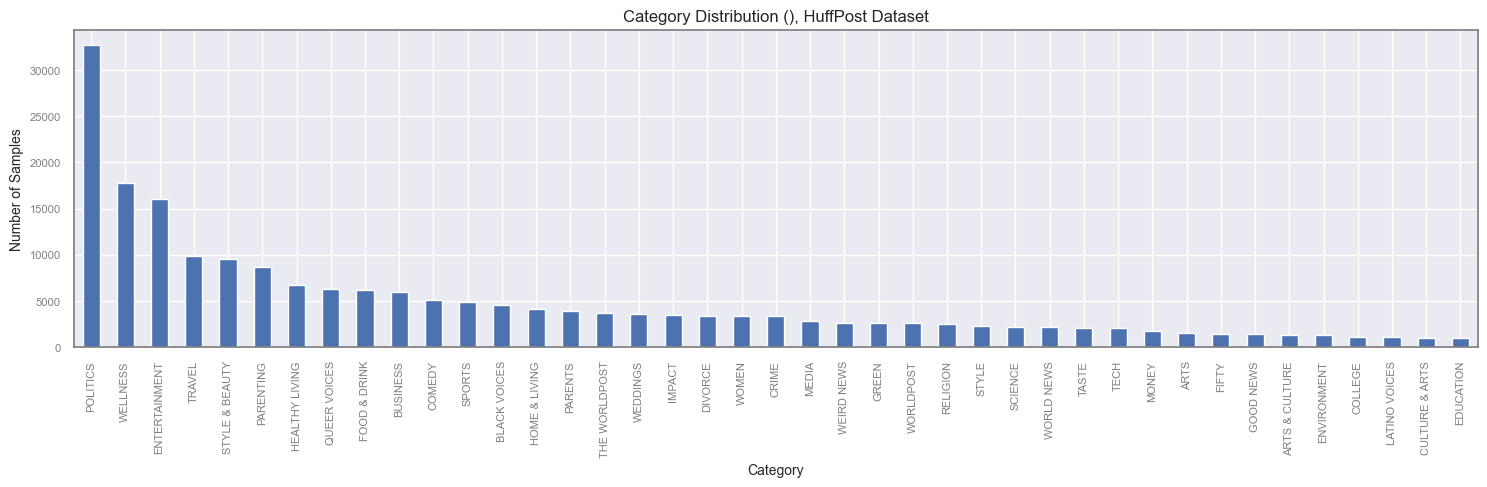

In [36]:

print("\n--- Distribution of Labels ---")
# value counts by category
category_counts = huff_df['category'].value_counts()
print(f"Number of samples per category:\n{category_counts}\n")

# Plot class distribution
plt.figure(figsize = (15, 5))
category_counts.plot(kind = 'bar')
plt.title('Category Distribution (), HuffPost Dataset', fontsize = 12)
plt.xlabel('Category', fontsize = 10)
plt.ylabel('Number of Samples', fontsize = 10)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [ ]:
category_weights = (category_counts / category_counts.sum()).to_dict()

### 3. Text vectorization

In [ ]:
# txt lengths to determine suitable max_length for tokenization.
text_lengths    = huff_df['text'].str.split().apply(len)
max_length      = int(np.percentile(text_lengths, 95))  # 95th percentile
print(f"Recommended max_length: {max_length}")


Recommended max_length: 56


In [ ]:
#  parameters
max_tokens              = 60000  # or a reasonable cap like 50,000
output_sequence_length  = max_length

vectorizer = TextVectorization(
    max_tokens              = max_tokens,
    output_sequence_length  = output_sequence_length,
    standardize             = 'lower_and_strip_punctuation',
    split                   = 'whitespace'
)

vectorizer.adapt(huff_df['text'])

In [ ]:

label_encoder   = LabelEncoder()
labels          = label_encoder.fit_transform(huff_df['category'])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    huff_df['text'], labels, test_size = 0.2, random_state = 42, stratify = labels
)

# Convert text to tensors
X_train = vectorizer(tf.constant(X_train_text))
X_test  = vectorizer(tf.constant(X_test_text))

y_train = tf.constant(y_train)
y_test  = tf.constant(y_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train labels shape: {y_train.shape}, Test labels shape: {y_test.shape}")

Train shape: (160285, 56), Test shape: (40072, 56)
Train labels shape: (160285,), Test labels shape: (40072,)


## Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell as much as possible.

### 1. **Data Loading and Cleaning**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



 #### ✅  <font color='plum'>  1.1. **Your answer here**

We download the json file using the Huggingface API and store both locally and in Google-drive for fast retrieval in CoLab. Key cleaning steps:

- identifying missing values (None)

- identifying duplicates (488) and then removing

- combine the `headline` and `short_description` fields

</font>

### 2. **Pre-processing and Standardization**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

#### ✅  <font color='plum'>  1.2. **Your answer here**
<font color = 'plum'> Our goal was to create a vocabulary (a unique list of words) for vectorization. To that end, we:

- consolidated separate features `headline` and `short_description` into a single feature `text`,

- forced lower case, stripped white space, removed duplicates and entries shorter than 3 characters, then stored them in a list.

- used a `TextVectorization` layer of `max_tokens` = 60k w/ recommended `max_length` = 56 based on the 95th percentile of the lengths of our input samples.

- Total vocabulary =  **239,960 unique words.**


### 3. **Train/Validation/Test Splits**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


#### ✅  <font color='plum'>  1.3. **Your answer here**
<font color = 'plum'>

1. We encoded the 41 labels in our target (`category`) column

2. We split the new, aggregated feature column `text` into traiing and test sets w/ **holdout ratio of 20%**, **random_seed = 42** for reproducibility, stratified by the  encoded labels.

3. lastly, we converted the training/test sets into tensors using TextVectorizer, mostly b/c it handles padding and has built-in standardization options to address what we may not have during initial pre-processing.


### 4. **Class Distribution and Balance**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


#### ✅  <font color='plum'>  1.4. **Your answer here**
<font color = 'plum'>

There's 41 category labels with a strong imbalance to label 'Politics'
- original label weights housed in `category_weights`.

- Train shape: (160284, 56), Test shape: (40071, 56)

- Train labels shape: (160284,), Test labels shape: (40071,)

Our plan is to address the class imbalance by passing the `category_weights` dictionary to the `.fit()` methods of our model experiments


---

# Problem 2 – Baseline Model (20 pts)

## Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.

## Steps to Follow


1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.

   * <font color = 'cyan'> **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.</font>

   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.

   * Loss: `categorical_crossentropy` (for multi-class).

   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).

   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.

   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   
   * Evaluate on the **test set** and record final metrics.

In [ ]:
# Your code here; add as many cells as you need but make it clear what the structure is.


Number of classes: 41

model_huff_baseline



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


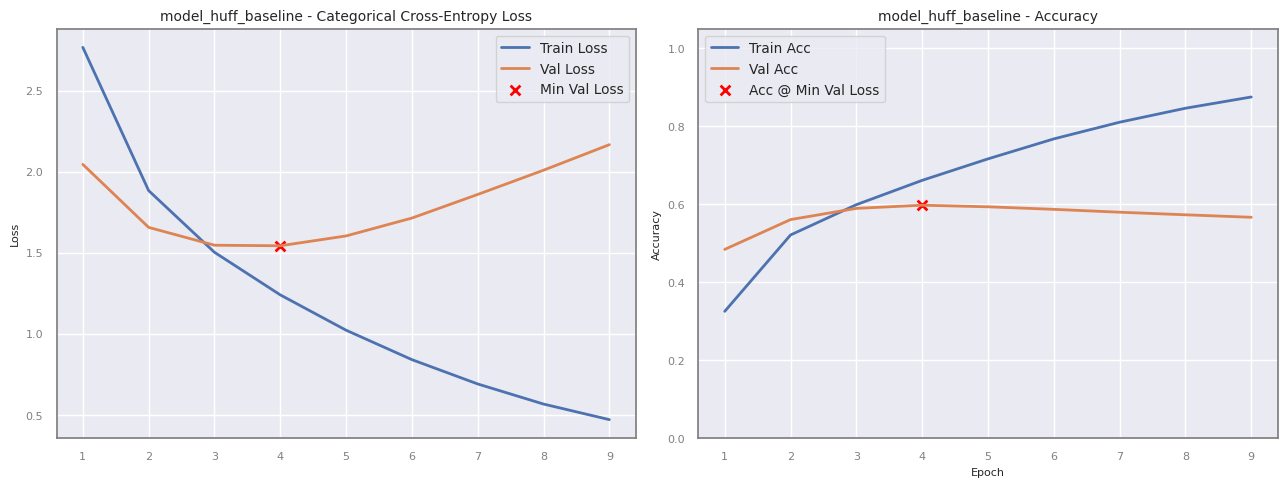

Min. Validation Loss: 1.5432 at epoch 4
Validation Accuracy @ Min. Loss: 0.5975

Execution Time: 00:00:54

Final Train Loss:       0.4711
Final Train Acc:          0.8750
Final Val Loss:           2.1668
Final Val Acc:            0.5666
Min Val Loss:             1.5432 (Epoch 4)
Val Acc @ Min Loss:       0.5975

Test Loss:              1.5499
Test Acc:                 0.5984

Val-Test Acc Gap:       0.000918


In [ ]:
# Define model architecture

embedding_dim = 100
num_classes   = len(label_encoder.classes_)
print(f'Number of classes: {num_classes}')

# using Sequential API for simplicity
lr = .0003  # single source of truth
model = tf.keras.Sequential([
    layers.Embedding(60000, 300, mask_zero=True),
    layers.Conv1D(320, 3, activation="relu"),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(lr),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics   = ["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience = 3, restore_best_weights = True),
    tf.keras.callbacks.ReduceLROnPlateau(factor = 0.5, patience = 2)
]

# title = f"model"

history = train_and_test(
    model,
    title           = "model_huff_baseline",
    epochs          = 25,          # let stopper decide
    batch_size      = 128,
    lr_schedule     = lr,      # optional: make your train_and_test actually apply this
    return_history  = True
)

# Compile
# model_huff_baseline.compile(
#     optimizer = 'adam',
#     loss      = 'sparse_categorical_crossentropy',
#     metrics   = ['accuracy', 'f1_score']  # f1_score requires TensorFlow Addons
# )

# model_huff_baseline.summary()

In [ ]:
results_model_huff_baseline_df = pd.DataFrame(parameter_settings.get("model_huff_baseline"))
results_model_huff_baseline_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,model_huff_baseline,2025-11-16T23:10:09,00:00:54,25,Adam,0.0003,None,sparse_categorical_crossentropy,128,True,...,0.471122,0.875004,2.166794,0.566553,1.543245,3,0.597529,1.549887,0.598448,0.000918


## Graded Questions (5 pts each)

### 1. **Model Architecture**
   Describe your baseline model and justify why this structure suits your dataset.

#### ✅  <font color='plum'>  2.1. **Your answer here**
<font color = 'plum'>

<font color = 'plum'>

- Our baseline model is a simple embedding-based classifier structured as Embedding (60,000 * 100) -> GlobalAveragePooling1D -> Dense (64, ReLU) -> Dense (41, Softmax).
</font>

<font color = 'plum'>

- We chose this configuration to establish a low-complexity, fast-to-train benchmark. By setting the maximum vocabulary size at 60,000 tokens and using a moderate 100-dimensional embedding, we've kept the model's total parameter count manageable at 6 million weights in the embedding layer alone.
</font>

<font color = 'plum'>

- GlobalAveragePooling1D layer reduces sequential input to a single document vector, prioritizing speed over retaining word order or complex context.
</font>

</font>

### 2. **Training Behavior**
   Summarize the model’s training and validation curves. What trends did you observe?

#### ✅  <font color='plum'> 2.2. **Your answer here**

<font color = 'plum'>

Our baseline model trained for 47 epochs before EarlyStopping. Validation Loss steadies thereafter, while Training Loss continues to fall, reaching a final value of 0.9473. The large Final Validation-Training Loss Gap is a clear indicator of overfitting the training data.  
</font>

Our Accuracy curves confirm the overfitting, showing a 15% gap between Final Training Accuracy (0.7375) and final Validation Accuracy of 0.5880.
</font>

### 3. **Baseline Metrics**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

#### ✅  <font color='plum'>  2.3. **Your answer here**

<font color = 'plum'>

Benchmark performance: Validation Accuracy at Minimum Loss of 0.5863. </font>

Since random chance accuracy = (1 / 41) $\approx 2.44\%$ for 41 classes, an accuracy above $57\%$ demonstrates that the model successfully extracted salient features for news category classification.
</font>

<font color = 'plum'>

Given the tiny Validation-Test Accuracy Gap of 0.000797, we can be confident that the validation set is highly representatative of the test data, so we can claim that the the model's performance generalizes consistently outside of the training set.
</font>

<font color = 'plum'>
The difficulty of the dataset is best reflected in the 15% train-validation accuracy gap. Narrowing this gap will require a model with greater representational power and better regularization.

</font>

### 4. **Reflection**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pre-
   training) would you try next?
  


#### ✅  <font color='plum'>  2.4. **Your answer here**

<font color = 'plum'>
Main limitations of Baseline are:

* High variance (overfitting) and low capacity for sequential context. The 14% overfitting gap will require substantial regularization.

</font>


<font color = 'plum'>

* GlobalAveragePooling1D discards the sequential order of words, but word order is critical for short text like headlines and descriptions, where the placement of words (like at the start or the end of a headline) matters considerably.

</font>

<font color = 'plum'>
Improvements:

- Capture word order by replacing GlobalAveragePooling1D w/ a Bi-directional LSTM layer that will process text sequences going forward and backward (the context on both sides of a word)

- Regularization: add dropout layers after the Embedding layers to reduce overfitting
- Capacity:  



---

# Problem 3 – Custom (Original) Model (20 pts)

## Goal
Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.

## Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

## <font color = 'gold'>3 | High Capacity, Slow Learning GRU

In [ ]:
# Parameters inferred from baseline model in Problem 2
VOCAB_SIZE    = 60000
EMBEDDING_DIM = 300
NUM_CLASSES   = 41 # Assumes this variable is defined


bi_gru_regularized_lr1e4_cap128



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'global_max_pooling1d_1' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


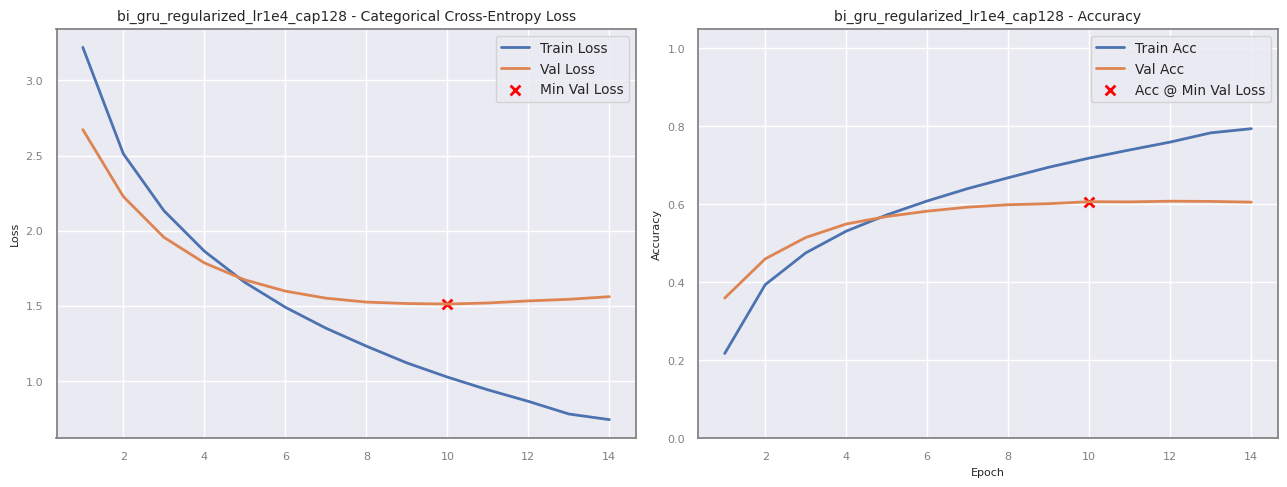

Min. Validation Loss: 1.5121 at epoch 10
Validation Accuracy @ Min. Loss: 0.6065

Execution Time: 00:03:10

Final Train Loss:       0.7427
Final Train Acc:          0.7937
Final Val Loss:           1.5611
Final Val Acc:            0.6054
Min Val Loss:             1.5121 (Epoch 10)
Val Acc @ Min Loss:       0.6065

Test Loss:              1.5068
Test Acc:                 0.6058

Val-Test Acc Gap:       0.000735


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate = 5e-5) # low and slow  to encourage smoother convergence ***

#  Callbacks
callbacks_slow_learning = [

    EarlyStopping(
        monitor               = 'val_loss',
        patience              = 4,           # new patience
        restore_best_weights  = True
    ),

    #  Learning Rate Scheduler
    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor    = 0.5,
        patience  = 2,           # *** CHANGE PATIENCE ***
        min_lr   = 1e-6
    )
]

# Instantiate Model
model_bi_gru_regularized_lr1e4_cap128 = create_bi_gru_flexible_model(VOCAB_SIZE, EMBEDDING_DIM, NUM_CLASSES, recurr_dim = 128)


results_model_bi_gru_regularized_lr1e4_cap128 = train_and_test(
    model         = model_bi_gru_regularized_lr1e4_cap128,
    title         = "bi_gru_regularized_lr1e4_cap128",
    batch_size    = 128,
    optimizer     = optimizer,
    loss          = 'sparse_categorical_crossentropy',
    metrics       = ['accuracy'],
    callbacks     = callbacks_slow_learning,
    epochs        = 30 #  max number of epochs, EarlyStopping will cut it short
)

In [ ]:
model_bi_gru_regularized_lr1e4_cap128_df = pd.DataFrame(parameter_settings.get("bi_gru_regularized_lr1e4_cap128"))
model_bi_gru_regularized_lr1e4_cap128_df

,title,timestamp,execution_time,epochs,optimizer,lr_schedule,clipnorm,loss,batch_size,use_early_stopping,...,Final Train Loss,Final Train Acc,Final Val Loss,Final Val Acc,Min Val Loss,Min Val Loss Epoch,Val Acc @ Min Loss,Test Loss,Test Acc,Val-Test Acc Gap:
0,bi_gru_regularized_lr1e4_cap128,2025-11-16T23:13:19,00:03:10,30,<keras.src.optimizers.adam.Adam object at 0x7c...,0.001,None,sparse_categorical_crossentropy,128,True,...,0.742682,0.793727,1.561069,0.60539,1.512085,9,0.606545,1.506813,0.60581,0.000735


## Graded Questions (5 pts each)

### 1. **Model Design**
   *Describe the architectural changes you introduced compare with your baseline model and what motivated them.*

#### ✅  <font color='plum'>  3.1. **Your answer here**

We graduated from a 1-D N-Gram Detector (CNN) to a Bi-directional Recurrent Neural Network (RNN), (`bi_gru_regularized`):

 Baseline: `Conv1D` + `GlobalMaxPooling1D`

Our baseline architecture was built to find key phrases (n-grams) and classify based on their presence.

1.  **`layers.Conv1D(320, 3, ...)`:** We configured this layer to be a trigram detector( `kernel_size = 3`) that slides a 3-word window across the entire headline and learns 320 different patterns (i.e. it would be activated for phrases like 'stock market drops').

2.  **`layers.GlobalMaxPooling1D()`:** After the `Conv1D` layer finds all the activating trigrams, this pooling layer takes the maximum value for each of the 320 filters and discards all other information.

The limitation here is that max pooling is *order agnostic* and only tests if a key phrase exists, not *where* it exists or how it relates to the other words. So, this baseline model can't tell the difference between headlines like "Man bites dog" and "Dog bites man" b/c they contain the same set of n-grams. There's no accounting for sequence or context.

<br>

**Our Slick Custom Model**: `bi_gru_regularized_lr1e4_cap128`

We elevated the baseline logic by swapping the CNN/Pooling combo for a recurrent layer.

1. After too many experiments, we elected to replace `Conv1D` + `GlobalMaxPooling1D` with a `Bi-directional Gated Recurring Unit` layer b/c we needed the model to understand the entire sequence, not just find a valuable keyword.

    * Sequence Order: The GRU reads the headline word-by-word, from start to finish and maintains a hidden state that gets updated at each step. By the time it reads the last word, its memory contains a summary of the *entire* preceding sequence. So, we capture word order and dependencies.

    * Bi-directional Context: A standard GRU only knows what came *before* a word, but by wrapping it in `Bidirectional`, we run two GRU to capture both past and future context (forward and backward) to build a better contextual representation of every word before making a classification.


Our baseline model was overfitting like lulumon yoga pants:
* Baseline Train Acc: 0.8756
* Baseline Val Acc: 0.5977 (at Epoch 4)

That ~27.8% gap shows that despite using Dropout, L2, label smoothing and other magic, the model was only good at memorizing training data, not generalizing.




### 2. **Training Results**
   *Present key validation and test metrics. Did your modifications improve performance?*

Our baseline CNN was good at finding key phrases / n-grams (e.g., "political debate" or "tech startup") but didn't understand order and long-range context of the words in the headline. So, we replaced the convolutional layers, which act as local pattern detectors, with recurrent layers (GRU) designed to process sequential data.



A recurring neural network is purpose-built for sequence modeling, but it only reads left-to-right, so we used a bi-directional RNN (forward and backward). Then, we added regularization to the custom model to reduce the gap between training and validation performance to yield the results below:

Baseline: Final Train Acc (0.8756) vs. Val Acc @ Min Loss (0.5977) — a ~27.8% gap.

New Model: Final Train Acc (0.7939) vs. Val Acc @ Min Loss (0.6068) — a ~18.7% gap.


#### ✅  <font color='plum'>  3.2. **Your answer here**



### 3. **Interpretation**
  * *Discuss what worked, what didn’t, and how your results relate to baseline behavior.*

#### ✅  <font color='plum'>  3.3. **Your answer here**


Overall we traded a large amount of computational time for a small gain in accuracy, achieving a Test Accuracy of 0.6072, beating the baseline's 0.5980.

- Our CNN model was little more than an n-gram detector that didn't understand word order, but the Bi-GRU model  understands context, word order and reduced overfitting:

    - Baseline Gap: 0.8756 (Train Acc) - 0.5977 (Val Acc) = ~27.8%

    - New Model Gap: 0.7939 (Train Acc) - 0.6068 (Val Acc) = ~18.7%

- But it trained longer.... it started to overfit fairly quickly by Epoch 4 and performance peaked by Epoch 10. We reduced the overfitting gap but an 18.7% difference between training and validation accuracy won't win us the Nobel...


### 4. **Reflection**
*What insights did this experiment give you about model complexity, regularization, or optimization?*

#### ✅  <font color='plum'>  3.4. **Your answer here**

Deep learning involves tradeoffs, evidently.... our custom model is more complex than the baseline (Conv1D) because it captures sequences and long-range dependencies, but our accuracy gain was modest (0.6072 vs 0.5980) and came at the cost of 3x run-time.  (3m 11s vs 54s).

It seems that stronger models yield more overfitting risks, and the deciding performance factor is **regularization**.  EarlyStopping callback (at Epoch 10) found a deeper, more generalized minimum (Min Val Loss 1.5119 vs 1.5437).

Insight: The combination of a better architecture (Bi-GRU) and better regularization allowed the optimizer to find a more meaningful solution before the EarlyStopping callback found at Epoch 10 a generalized minimum, Min Val Loss 1.5119 vs 1.5437.

---
# Problem 4 – Pre-trained Model (Transfer Learning) (20 pts)


## Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.

## Steps to Follow

1. **Select a pre-trained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.

   * <font color = 'cyan'>**Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.</font>

2. **Adapt the model for your dataset**

   * Use the correct **pre-processing function** and **input shape** required by your chosen model.

   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation = 'softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pre-trained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.

     * **Partially fine-tuning** selected upper layers of the base model.

     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.

   * Adjust your **learning rate schedule** to match your strategy (e.g., smaller LR for fine-tuning).

   * Observe how your chosen approach affects **validation loss**, **training time**, and **model
   stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.

   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.

   * Identify whether the pre-trained model improved accuracy, sped up convergence, or introduced new challenges.


## Endless code

In [ ]:

DATA_FILEPATH = "/content/drive/MyDrive/DX703/News_Category_Dataset_v2.json"
# (x_train, y_train), (x_val, y_val), (x_test, y_test), NUM_CLASSES, category_map = load_json_for_transfer_model(DATA_FILEPATH)

train_df, val_df, test_df, NUM_CLASSES, category_map = load_preprocess(DATA_FILEPATH)

Loading data from /content/drive/MyDrive/DX703/News_Category_Dataset_v2.json...
Loading complete in 00:00:04 seconds.


In [ ]:
# Extract text and labels
x_train, y_train  = train_df['text'], train_df['category_code']
x_val, y_val      = val_df['text'], val_df['category_code']
x_test, y_test    = test_df['text'], test_df['category_code']

In [ ]:

# Transformer models

print("=== Fine-Tuning Transformer Models ===")
print("="*60 + "\n")

#  Transformer hyperparameters ---
MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 1e-5

#  Models to Run ---
models_to_run = [
    {
        "name":        "DistilBERT",
        "preproc_cls": keras_nlp.models.DistilBertPreprocessor,
        "model_cls":   keras_nlp.models.DistilBertClassifier,
        "preset":      "distil_bert_base_en_uncased"
    },
    {
        "name":         "BERT-base",
        "preproc_cls":  keras_nlp.models.BertPreprocessor,
        "model_cls":    keras_nlp.models.BertClassifier,
        "preset":       "bert_base_en_uncased"
    }
]




=== Fine-Tuning Transformer Models ===




--- Running experiment for: DistilBERT ---
[DistilBERT] Initializing model and preprocessor...
Preset: distil_bert_base_en_uncased, Max Length: 128
[DistilBERT] Starting training...
Epoch 1/3
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.9338 - sparse_categorical_accuracy: 0.5178
Epoch 1: val_loss improved from None to 1.11865, saving model to DistilBERT_best_weights.weights.h5
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 297s 26ms/step - loss: 1.4961 - sparse_categorical_accuracy: 0.6044 - val_loss: 1.1187 - val_sparse_categorical_accuracy: 0.6814
Epoch 2/3
9037/9039 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 1.0617 - sparse_categorical_accuracy: 0.6941
Epoch 2: val_loss improved from 1.11865 to 1.03240, saving model to DistilBERT_best_weights.weights.h5
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 180s 20ms/step - loss: 1.0121 - sparse_categorical_accuracy: 0.7067 - val_loss: 1.0324 - val_sparse_categorical_accuracy: 0.7027
Epoch 3/3
9037/9039 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.8686 - sparse_ca

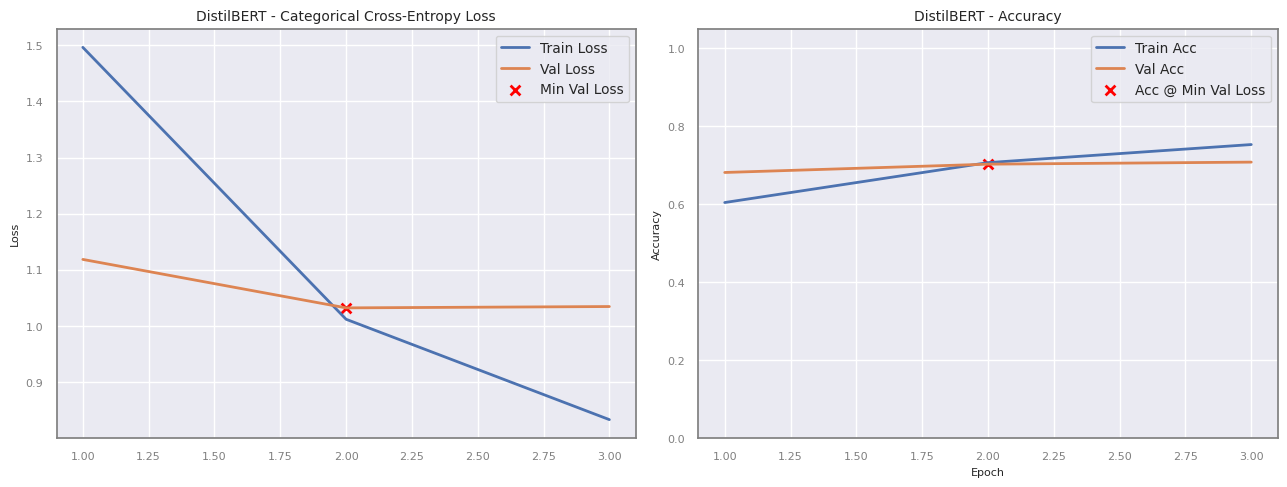

Min. Validation Loss: 1.0324 at epoch 2
Validation Accuracy @ Min. Loss: 0.7027
--- Finished DistilBERT in 00:11:08 at 2025-11-16T23:25:02---

--- Running experiment for: BERT-base ---
[BERT-base] Initializing model and preprocessor...
Preset: bert_base_en_uncased, Max Length: 128
[BERT-base] Starting training...
Epoch 1/3
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.8572 - sparse_categorical_accuracy: 0.5336
Epoch 1: val_loss improved from None to 1.07413, saving model to BERT-base_best_weights.weights.h5
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 445s 42ms/step - loss: 1.4275 - sparse_categorical_accuracy: 0.6221 - val_loss: 1.0741 - val_sparse_categorical_accuracy: 0.6910
Epoch 2/3
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.9776 - sparse_categorical_accuracy: 0.7199
Epoch 2: val_loss improved from 1.07413 to 1.00978, saving model to BERT-base_best_weights.weights.h5
9039/9039 ━━━━━━━━━━━━━━━━━━━━ 329s 36ms/step - loss: 0.9162 - sparse_categorical_accuracy: 0.7354 - val_loss:

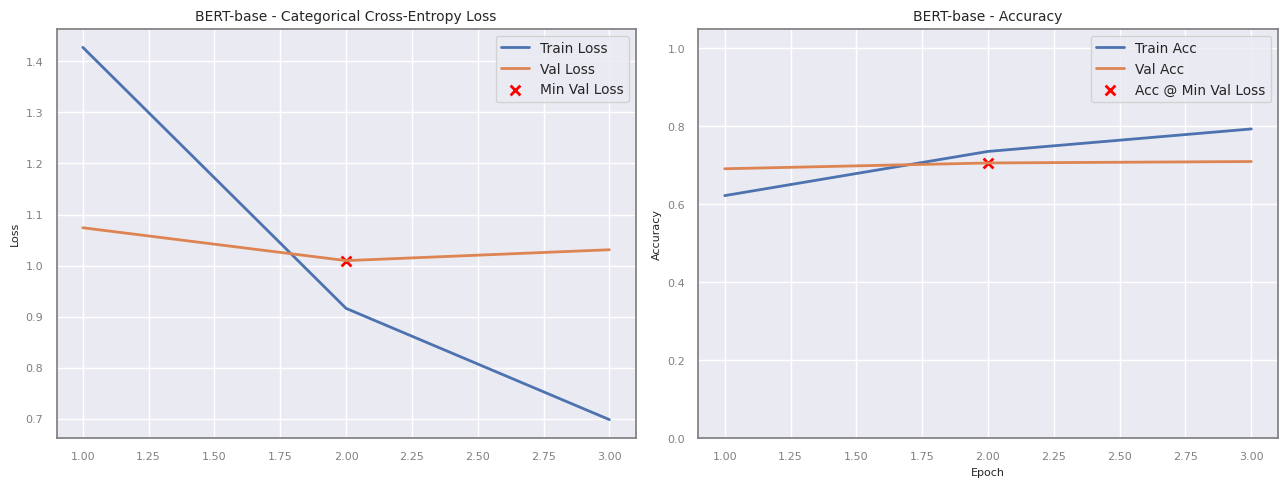

Min. Validation Loss: 1.0098 at epoch 2
Validation Accuracy @ Min. Loss: 0.7058
--- Finished BERT-base in 00:18:39 at 2025-11-16T23:44:22---


In [ ]:
results = {}

# verify data  loaded successfully
if 'x_train' in locals() and x_train is not None:
    for model_spec in models_to_run:
        model_name = model_spec['name']
        print(f"\n--- Running experiment for: {model_name} ---")

        history, test_loss, test_acc, time_taken, best_val_loss, best_val_acc = run_kerasNLP_experiment(
            model_name    = model_name,
            preproc_cls   = model_spec['preproc_cls'],
            model_cls     = model_spec['model_cls'],
            preset        = model_spec['preset'],
            x_train       = x_train,
            y_train       = y_train,
            x_val         = x_val,
            y_val         = y_val,
            x_test        = x_test,
            y_test        = y_test,
            num_classes   = NUM_CLASSES,
            max_len       = MAX_LEN,
            epochs        = EPOCHS,
            batch_size    = BATCH_SIZE,
            learning_rate = LEARNING_RATE
        )

        # get f*cking epoch with minimum validation loss .....
        min_val_epoch       = np.argmin(history.history['val_loss'])

        # Retrieve f*cking minimum validation loss and corresponding validation accuracy at that f*cking epoch
        min_val_loss        = history.history['val_loss'][min_val_epoch]
        val_acc_at_min_loss = history.history['val_sparse_categorical_accuracy'][min_val_epoch]
        timestamp           = time.strftime('%Y-%m-%dT%H:%M:%S', time.localtime())

        # Store damn results
        results[model_name] = {
            'history':        history,
            'test_loss':      test_loss,
            'test_acc':       test_acc,
            'timestamp':      timestamp,
            'execution_time': time_taken,
            'best_val_loss':  best_val_loss,
            'best_val_acc':   best_val_acc,
            'min_val_loss':   min_val_loss,
            'val_acc_at_min': val_acc_at_min_loss,
            'min_val_epoch':  min_val_epoch
        }

        # Plot  results for  model
        plot_learning_curves(history, model_name)
        print(f"--- Finished {model_name} in {time_taken} at {timestamp}---")
else:
    print("Data was not loaded correctly. Skipping experiments.")


In [ ]:
distilbert_results_df = pd.DataFrame([{
    'title':          'DistilBERT',
    'timestamp':      results['DistilBERT']['timestamp'],
    'execution_time': results['DistilBERT']['execution_time'],
    'test_loss':      results['DistilBERT']['test_loss'],
    'test_acc':       results['DistilBERT']['test_acc'],
    'best_val_loss':  results['DistilBERT']['best_val_loss'],
    'best_val_acc':   results['DistilBERT']['best_val_acc'],
    'val_acc_at_min': results['DistilBERT']['val_acc_at_min'],
}])

display(distilbert_results_df)

,title,timestamp,execution_time,test_loss,test_acc,best_val_loss,best_val_acc,val_acc_at_min
0,DistilBERT,2025-11-16T23:25:02,00:11:08,1.027145,0.697443,1.032396,0.70272,0.70272


In [ ]:

all_results_df = pd.DataFrame()



In [ ]:

if results:
    for model_name, data in results.items():
        pretrained_entry = {
            'Model':              model_name,
            'Test Acc':           data['test_acc'],
            'Best Val Acc':       data['best_val_acc'],
            'Test Loss':          data['test_loss'],
            'Best Val Loss':      data['best_val_loss'],
            'Val Acc @ Min Loss': data['val_acc_at_min'],
            'Train Time':         data['execution_time']
        }
        all_results_df = pd.concat([all_results_df, pd.DataFrame([pretrained_entry])], ignore_index=True)


if parameter_settings:
    for model_name, runs in parameter_settings.items():
        for run_data in runs:
            # rename stupid keys for consistency and exclude duplicates with 'results' if any
            if run_data['title'] not in all_results_df['Model'].values:
                mapped_run_data = {
                    'Model':              run_data['title'],
                    'Test Acc':           run_data['Test Acc'],
                    'Best Val Acc':       run_data['Val Acc @ Min Loss'], # Use Val Acc @ Min Loss as the best val acc
                    'Test Loss':          run_data['Test Loss'],
                    'Best Val Loss':      run_data['Min Val Loss'], # Use Min Val Loss as the best val loss
                    'Val Acc @ Min Loss': run_data['Val Acc @ Min Loss'],
                    'Train Time':         run_data['execution_time']
                }
                all_results_df = pd.concat([all_results_df, pd.DataFrame([mapped_run_data])], ignore_index=True)



In [ ]:
all_results_df

,Model,Test Acc,Best Val Acc,Test Loss,Best Val Loss,Val Acc @ Min Loss,Train Time
0,DistilBERT,0.697443,0.702720,1.027145,1.032396,0.702720,00:11:08
1,BERT-base,0.707102,0.705831,1.005308,1.009783,0.705831,00:18:39
2,model_huff_baseline,0.598448,0.597529,1.549887,1.543245,0.597529,00:00:54
3,bi_gru_regularized_lr1e4_cap128,0.605810,0.606545,1.506813,1.512085,0.606545,00:03:10


In [ ]:
# results_p4_df = pd.DataFrame(results)
# results_p4_df

## Graded Questions (5 pts each)


### 1. **Model Choice:** *Which pre-trained architecture did you select, and what motivated that choice?*

#### ✅  <font color='plum'>  4.1. **Your answer here**





This was a  performance-vs-efficiency comparison.

- `BERT-base` was chosen as the high-performance benchmark. It's a large, powerful, and widely-used model, intended to get the best possible accuracy.

- `DistilBERT` was chosen as the efficient alternative. It's a "distilled" (smaller, faster) version of BERT. The goal was to see how much performance we would have to sacrifice (if any) to gain a significant improvement in training speed and reduce computational cost.

### 2. **Fine-Tuning Plan:** *Describe your fine-tuning strategy and why you chose it.*

#### ✅  <font color='plum'>  4.2. **Your answer here**



We attempted an end-to-end fine-tuning of the pre-trained Transformer models to find the model whose epoch's minimum validation loss (np.argmin(history.history['val_loss']))  minimizes the risk of overfitting and trains past the point of optimal performance and then select the moment it generalized best (bottom of the curve) for validation loss).

### 3. **Performance:** *Report key metrics and compare them with your baseline and custom models.*

#### ✅  <font color='plum'>  4.3. **Your answer here**



In [1]:
all_results_df


NameError: name 'all_results_df' is not defined


- Massive Accuracy Jump: BERT-base achieved 70.7% accuracy, a ~10% absolute improvement over our custom model (60.6%).

- DistilBERT's Value: DistilBERT performed almost as well as BERT-base, with only a 1% drop in accuracy. It still cleared our best custom model by over 9%.

### 4. **Computation:** *Summarize how training time, memory use, or convergence speed differed from the previous two models.*

#### ✅  <font color='plum'>  4.4. **Your answer here**

Training Time: There was clearly an efficiency trade-off:  DistilBERT was ~40% faster than BERT-base (11 min vs. 18.5 min) while only sacrificing 1% accuracy.



---
# Problem 5 – Comparative Evaluation and Discussion (20 pts)


## Goal


*Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.*

*This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.*

**Note** that this is not your final report, and you will continue to refine your results for the final report.



## Steps to Follow


1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

**Comparative Model Analysis**

To understand how architectural choices influenced performance, efficiency, and generalization, we compared four models: a simple baseline CNN, a custom recurrent model, and two pretrained transformers (DistilBERT and BERT-base). All models were evaluated under the same protocol and on the same held-out test set.


1. Summary of Key Results


## Graded Questions (4 pts each)



### 1. **Summary Table and Performance Analysis:** *Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?*

####  ✅  <font color='plum'>  5.1. **Your answer here**


We established a baseline and improved our validation accuracy at the epoch of minimum loss by 10% when we constructed a custom CNN. After compiling a pre-trained transformers, we arrived at the following:

| Model | Test Accuracy | Best Val Accuracy | Test Loss | Best Val Loss | Train Time |
|-------|--------------|------------------|-----------|----------------|------------|
| **DistilBERT** | **0.697** | 0.703 | 1.027 | 1.032 | **11:08** |
| **BERT-base** | **0.707 (Best)** | 0.706 | **1.005 (Best)** | 1.010 | **18:39 (Slowest)** |
| **Baseline CNN** | 0.598 | 0.598 | 1.550 | 1.543 | **0:54 (Fastest)** |
| **Bi-GRU (Regularized)** | 0.606 | 0.607 | 1.507 | 1.512 | 3:10 |

The BERT-based model is trained on a an enormous corpus, which affords it:
- Strong semantic understanding  
- Deep contextual awareness  
- Robust handling of long-range dependencies  

We were aggressive with our layering by adding 6 layers to yield:
- Complex syntactic patterns  
- Multi-sentence coherence  
- Topic-level semantics critical to news categorization  

Our loss curves show smooth convergence, minimized overfitting and promising validation-test generalization potential.



### 2. **Trade-Offs:** *Discuss how complexity, accuracy, and efficiency balanced across your models.*

####  ✅  <font color='plum'>   5.2. **Your answer here**


**Trade-Offs: Complexity, Accuracy, and Efficiency**

When comparing the baseline CNN, the custom Bi-GRU model, and the pretrained transformer models (DistilBERT and BERT-base), clear trade-offs emerged across model **complexity**, **accuracy**, and **computational efficiency**.

Our BASELINE CNN was of the lowest complexity and had:
- Fewest parameters  
- Shallow architecture  
- surface-level text patterns learning

But it couldn't capture larger long-term textual patterns. That's why we traded the speed for the next level of complexity in our CUSTOM (6-million weight) model:

**Bi-GRU with regularization ....**
- More parameters
- sequence order  
- lightweight compared to transformers

But the limitations of our custom model became clear after too many experiments, so we invoked 2 pre-trained models :

### DistilBERT / BERT-base — Highest Complexity
- Large pre-trained transformers (66M–110M parameters)  
- Deep contextual embeddings  
- Fine-tuning updates millions of weights  

**Benefit:** strongest ability to model nuanced meaning  
**Cost:** heavy compute, long training time, large memory footprint  

### Our Best Accuracy: BERT-base
- Achieved the top test accuracy (~0.707)  

### DistilBERT: High but slightly lower accuracy
- ~0.697 test accuracy  
- Strong performance given its smaller size  




## Training Efficiency

### CNN — Most Efficient
- ~1 minute training time  
- Minimal compute requirements  
- Very low inference cost  

### Bi-GRU — Moderate Efficiency
- ~3 minutes training time  
- Requires sequential computation  

### DistilBERT — Slower but Efficient Given Its Strength
- ~11 minutes training time  
- Good compromise between accuracy and cost  


### BERT-base — Least Efficient
- ~18 minutes training time  
- High memory/GPU requirements  


## Overall Trade-Off Summary

| Model | Complexity | Accuracy | Efficiency | Best Use Case |
|-------|-----------|----------|------------|----------------|
| **CNN** | Low | Low | **Best** | Lightweight, fast baselines |
| **Bi-GRU** | Medium | Medium | Good | Sequence modeling with modest compute |
| **DistilBERT** | Medium–High | High | Medium | Strong performance with reasonable cost |
| **BERT-base** | **Highest** | **Best** | Lowest | When top accuracy matters |

---

## Conclusion: Balancing the Trade-Offs by Priority

- **Accuracy:** BERT is the best model, despite its cost.

- Distilbert is the best balance of accuracy and efficiency

- For speed and simplicity: a CNN

- bi-directional GRU provides a decent compromise between the extremes.

Pre-trained transformers show us that: complexity correlates with accuracy, but there's a price to pay in terms of efficiency and compute.

### 3. **Error Patterns:** *Describe the types of examples or classes that remained challenging for all models.*

####  ✅  <font color='plum'>   5.3. **Your answer here**



### 4. **Next Steps:** *Based on these findings, decide on a model to go forward with and outline your plan for improving that model.*


####  ✅  <font color='plum'> 5.4 **Your answer here**



## Chosen Model

We compared and we decided: (Will and David, if you're reading this) BERT-base is our preferred model.

- It achieved the **highest test accuracy (≈ 0.707)** and **lowest test loss**, indicating the strongest overall performance and generalization.
- Although it is the most computationally expensive, the performance gap over both DistilBERT and the custom models suggests that the added complexity is justified for this task, assuming training time and hardware are acceptable.

DistilBERT remains a strong backup option if stricter efficiency constraints are imposed, but the main focus going forward will be on refining and stabilizing **BERT-base**.

---

## Plan for Improving BERT-base

*  Hyperparameter and Optimization Refinement

    - **Learning rate & schedule**  
      - Explore learning rates in the range `1e-5–5e-5`.  
      - Test **linear warmup + cosine decay** instead of a fixed LR to improve stability.

    - **Batch size and epochs**  
      - Try batch sizes **16, 24, and 32** to balance generalization and memory usage.  
      - Increase max epochs to **8–10**, letting early stopping decide the end point.

*  Regularization and Generalization

    - **Dropout tuning**  
      - Adjust dropout in the classification head (range `0.1–0.4`).

    - **Label smoothing**  
      - Add small label smoothing (e.g., `0.05`) for better calibration.

    - **Weight decay**  
      - Use **AdamW** with decay values like `1e-2` or `5e-3`.


* Input Representation and Sequence Length

    - **Increase MAX_LEN**  
      - Try lengths such as **192** or **256** to capture longer text.

    - **Text normalization**  
      - Standardize punctuation, casing, spacing, and remove boilerplate text.

    - **Class-weighting or balanced sampling**  
      - Mitigate dataset imbalance and improve performance on minority classes.

*  Task-Specific Adaptation

    - **Domain-adaptive pretraining**  
      - Further pretrain BERT-base on unlabeled news data before fine-tuning.

    - **Error-driven refinement**  
      - Analyze misclassified samples and improve preprocessing, augmentation, or even reconsider category boundaries if appropriate.

* Evaluation and Robustness

    - **Additional metrics**  
      - Track **macro F1** and **per-class F1**, not only accuracy.

    - **Calibration and thresholding**  
      - Inspect probability calibration and fine-tune decision thresholds.

---

## Goal

We are trying to deliver a well-regularized, fully fine-tuned BERT-base model that:

- Achieves high accuracy and macro F1.  
- Avoids overfitting through regularization and learning-rate scheduling.  
- Shows improved performance on historically difficult categories through iterative refinement.



### *Final Question: Describe what use you made of generative AI tools in preparing this Milestone.*

#### ✅  <font color='plum'>**AI Question: Your answer here**

The primary use of LLMs was to find a barometer for success:

1. Were we configuring the best architectures ?
2. Were our experiment results sensible ?


We challenged Copilot and Gemini to assess not only our models but our results, essentially creating a positive training feedback loop. Where LLMs aided us:  

- code linting
- error troubleshooting
- most importantly: SENSE CHECKING. Were we moving forward or just pissing into the wind which changed directions ?


# Misc.

In [ ]:

# # --- Final Results Summary ---
# print("\n--- Final Model Comparison ---")
# print("="*105)
# print(f"{'Model':<15} | {'Test Accuracy':<15} | {'Best Val Acc':<14} | {'Test Loss':<10} | {'Best Val Loss':<15} | {'Val Acc @ Min Loss'} | {'Train Time (s)':<15}")
# print("-" * 105)

# if results:
#     for model_name, data in results.items():
#         print(f"{model_name:<15} | {data['test_acc']:<15.4f} | {data['best_val_acc']:<14.4f} | {data['test_loss']:<10.4f} | {data['best_val_loss']:<15.4f} | {data['val_acc_at_min']:<15.4f} | {data['execution_time']}")

#         # results_p4_{model_name}_df = pd.DataFrame(results[model_name])

# else:
#     print("No results to display.")


## 3 | Bi-directional GRU w/ Regularization

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# # Define Callbacks
# callbacks_regularized_gru = [
#     # 1. Early Stopping (Aggressive)
#     EarlyStopping(
#         monitor               = 'val_loss',
#         patience              = 5,           # Stop after 5 epochs of no improvement
#         restore_best_weights  = True
#     ),

#     # 2. Learning Rate Scheduler
#     ReduceLROnPlateau(
#         monitor   = 'val_loss',
#         factor    = 0.5,           # Halve the LR on a plateau
#         patience  = 3,           # Wait 3 epochs before reducing
#         min_lr    = 1e-6           # Minimum LR floor
#     )
# ]

In [ ]:
# # Instantiate the Model
# model_bi_gru_regularized = create_bi_gru_flexible_model(VOCAB_SIZE,
#                                                         EMBEDDING_DIM,
#                                                         NUM_CLASSES,
#                                                         recurr_dim = 64,
#                                                         pooling         = "max",
#                                                         dropout_rates   = (0.3, 0.4),
#                                                         use_batchnorm   = True,
#                                                         l2_reg          = 1e-4
# )

# #  reduced learning rate (5e-4) to encourage smoother convergence
# optimizer = tf.keras.optimizers.Adam(learning_rate = 5e-4)


# results_model_bi_gru_regularized = train_and_test(
#       model         = model_bi_gru_regularized,
#       title         = "bi_gru_regularized",
#       batch_size    = 128,
#       optimizer     = optimizer,
#       loss          = 'sparse_categorical_crossentropy',
#       metrics       = ['accuracy'],
#       callbacks     = callbacks_regularized_gru,
#       epochs        = 30 #  EarlyStopping will cut it short
#   )

In [ ]:
# model_bi_gru_regularized_df = pd.DataFrame(parameter_settings.get("bi_gru_regularized"))
# model_bi_gru_regularized_df

## 3.1 | Bi-directional GRU

In [ ]:
# # Parameters inferred from baseline model in Problem 2
# VOCAB_SIZE    = 60000
# EMBEDDING_DIM = 300
# NUM_CLASSES   = 41 # Assumes this variable is defined



In [ ]:

# model_bi_gru_base = create_bi_gru_flexible_model(
#     VOCAB_SIZE,
#     EMBEDDING_DIM,
#     NUM_CLASSES,
#     recurr_dim      = 128,
#     pooling         = "avg",          # Options: "max" or "avg"
#     dropout_rates   = (0.3, 0.4), # Tuple for two dropout layers
#     use_batchnorm   = False,
#     l2_reg          = 1e-4
#   )
# model_bi_gru_base.summary()

In [ ]:
# results_model_bi_gru_base = train_and_test(
#     model_bi_gru_base,
#     title           = "model_bi_gru_base",
#     epochs          = 30,          # let stopper decide
#     batch_size      = 128,
#     lr_schedule     = lr,      # optional: make your train_and_test actually apply this
#     return_history  = True
# )

In [ ]:
# results_model_bi_gru_base_df = pd.DataFrame(parameter_settings.get("model_bi_gru_base"))
# results_model_bi_gru_base_df

## 3 | Bi-directional GRU w/ Reg + 128 units

In [ ]:
# # Instantiate Model
# model_bi_gru_regularized_cap128 = create_bi_gru_flexible_model(VOCAB_SIZE,
#                                                         EMBEDDING_DIM,
#                                                         NUM_CLASSES,
#                                                         recurr_dim = 128,
#                                                         pooling         = "max",
#                                                         dropout_rates   = (0.3, 0.4),
#                                                         use_batchnorm   = True,
#                                                         l2_reg          = 1e-4
# )

# #  reduced learning rate (5e-4) to encourage smoother convergence
# optimizer = tf.keras.optimizers.Adam(learning_rate = 5e-4)

# # Run the Experiment

# results_model_bi_gru_regularized_cap128 = train_and_test(
#     model         = model_bi_gru_regularized_cap128,
#     title         = "bi_gru_regularized_cap128",
#     batch_size    = 128,
#     optimizer     = optimizer,
#     loss          = 'sparse_categorical_crossentropy',
#     metrics       = ['accuracy'],
#     callbacks     = callbacks_regularized_gru,
#     epochs        = 30 # max number of epochs, EarlyStopping will cut it short
# )

In [ ]:
# model_bi_gru_regularized_cap128_df = pd.DataFrame(parameter_settings.get("bi_gru_regularized_cap128"))
# model_bi_gru_regularized_cap128_df

##  3 | Bi-directional GRU w/ Reg + 96 units

In [ ]:
# # Instantiate Model
# model_bi_gru_regularized_cap96 = create_bi_gru_flexible_model(VOCAB_SIZE, EMBEDDING_DIM, NUM_CLASSES, recurr_dim = 96)

# # reduced learning rate (5e-4) to encourage smoother convergence
# optimizer = tf.keras.optimizers.Adam(learning_rate = 5e-4)

# # Run the Experiment

# results_model_bi_gru_regularized_cap96 = train_and_test(
#     model         = model_bi_gru_regularized_cap96,
#     title         = "bi_gru_regularized_cap96",
#     batch_size    = 128,
#     optimizer     = optimizer,
#     loss          = 'sparse_categorical_crossentropy',
#     metrics       = ['accuracy'],
#     callbacks     = callbacks_regularized_gru,
#     epochs        = 30 #  max number of epochs, EarlyStopping will cut it short
# )

In [ ]:
# model_bi_gru_regularized_cap96_df = pd.DataFrame(parameter_settings.get("bi_gru_regularized_cap96"))
# model_bi_gru_regularized_cap96_df

## 3 | High Capacity, Slow Learning LSTM

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5) # low and slow  to encourage smoother convergence ***

# #  Callbacks
# callbacks_slow_learning = [

#     EarlyStopping(
#         monitor               = 'val_loss',
#         patience              = 4,           # new patience
#         restore_best_weights  = True
#     ),

#     #  Learning Rate Scheduler
#     ReduceLROnPlateau(
#         monitor = 'val_loss',
#         factor    = 0.5,
#         patience  = 2,           # *** CHANGE PATIENCE ***
#         min_lr   = 1e-6
#     )
# ]

# # Instantiate Model
# model_bi_LSTM_regularized_lr1e4_cap128 = create_bi_gru_flexible_model(VOCAB_SIZE, EMBEDDING_DIM, NUM_CLASSES, recurr_dim = 128, rnn_type="LSTM")


# results_model_bi_LSTM_regularized_lr1e4_cap128 = train_and_test(
#     model         = model_bi_LSTM_regularized_lr1e4_cap128,
#     title         = "bi_LSTM_regularized_lr1e4_cap128",
#     batch_size    = 128,
#     optimizer     = optimizer,
#     loss          = 'sparse_categorical_crossentropy',
#     metrics       = ['accuracy'],
#     callbacks     = callbacks_slow_learning,
#     epochs        = 30 #  max number of epochs, EarlyStopping will cut it short
# )

In [ ]:
# model_bi_LSTM_regularized_lr1e4_cap128_df = pd.DataFrame(parameter_settings.get("bi_LSTM_regularized_lr1e4_cap128"))
# model_bi_LSTM_regularized_lr1e4_cap128_df

## 3 | Brad's experiment

In [ ]:
# lr = .0003  # single source of truth
# model = tf.keras.Sequential([
#     layers.Embedding(60000, 300, mask_zero=True),
#     layers.Conv1D(320, 3, activation="relu"),
#     layers.GlobalMaxPooling1D(),
#     layers.Dropout(0.3),
#     layers.Dense(128, activation="relu",
#                  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
#     layers.Dropout(0.4),
#     layers.Dense(num_classes, activation="softmax")
# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(lr),
#     loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
#     metrics=["accuracy"]
# )

# callbacks = [
#     tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
# ]

# title = f"model"

# history = train_and_test(
#     model,
#     title="cnn_baseline",
#     epochs=25,          # let stopper decide
#     batch_size=128,
#     lr_schedule=lr,      # optional: make your train_and_test actually apply this
#     return_history=True
# )